# Forward modelling, fine grid Shepp–Logan

Self-contained notebook following Stride tutorials **02** (problem definition) and **03** (acoustic modelling).

- uses IsoAcousticDevito (tutorial 03) but no Mosaic workers
- multi-machine runs not needed for a single-process forward


## 1. Configuration

In [1]:
import os
import platform
from pathlib import Path

os.environ.setdefault("DISPLAY", ":0")

if platform.system() == "Darwin":
    os.environ["DEVITO_LANGUAGE"] = "C"
    for key in ("CFLAGS", "CXXFLAGS", "LDFLAGS"):
        os.environ.pop(key, None)

SANDBOX_DIR = Path.cwd()
assert SANDBOX_DIR.name == "sandbox", (
    f"Expected notebooks/sandbox, but current directory is {SANDBOX_DIR}"
)

print("Working directory:", SANDBOX_DIR)

Working directory: /Users/mp425/irp-mp425/friends/irp-ld2022/notebooks/sandbox


In [2]:
DOMAIN_M = 0.25          # 25 cm square domain
INTERIOR = (250, 250)    # fine grid (low dispersion)
F_CENTRE = 200e3         # Hz
N_CYCLES = 3
N_RECEIVERS = 64

SOS_WATER = 1500.0
SOS_SOFT = 1540.0
SOS_SKULL = 2800.0

PDE_KWARGS = dict(kernel="OT2", boundary_type="sponge_boundary_2")

## 2. Imports

Tutorial 03 runs the PDE locally(no mosaic.interactive() needed for forward)


In [3]:
import os

# Stride incorrectly requires DISPLAY even for Jupyter inline plotting
os.environ.setdefault("DISPLAY", ":0")

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from stride import (
    IsoAcousticDevito,
    Problem,
    ScalarField,
    Space,
    Time,
)
from stride.utils import wavelets
from skimage.data import shepp_logan_phantom
from skimage.transform import resize


## 3. Grid (tutorial 02 / 03)

CFL-stable time step from the finest spacing and maximum sound speed (skull).

In [4]:
# Where Stride writes HDF5 observed data (not the whole sandbox folder)
OUT_DIR = SANDBOX_DIR / "stride_output"
OUT_DIR.mkdir(exist_ok=True)

# Grid spacing [m]: 250 points span 0.25 m → ~1 mm between nodes
spacing = (
    DOMAIN_M / (INTERIOR[0] - 1),
    DOMAIN_M / (INTERIOR[1] - 1),
)
dx = min(spacing)

# CFL time step: stable for explicit FD (uses fastest speed = skull)
dt = 0.3 * dx / SOS_SKULL

# Record long enough for waves to cross the domain and return (2x diagonal travel time)
diag = DOMAIN_M * np.sqrt(2.0)
t_max = 2.0 * diag / SOS_WATER
num = int(np.ceil(t_max / dt)) + 1

# Spatial grid + PML padding (extra/absorbing) to soak up edge reflections
space = Space(
    shape=INTERIOR,
    extra=(20, 20),
    absorbing=(20, 20),
    spacing=spacing,
)
time = Time(start=0.0, step=dt, num=num)

# Stride problem bundles grid, medium, geometry, acquisitions
problem = Problem(
    name=f"shepp_logan_{INTERIOR[0]}_{N_RECEIVERS}rc",
    space=space,
    time=time,
    output_folder=str(OUT_DIR),
    input_folder=str(OUT_DIR),
)

# Points-per-wavelength check (want >=6 for low dispersion at 200 kHz)
ppw = SOS_WATER / (F_CENTRE * spacing[0])
print(problem.grid)
print(f"dx={dx*1e3:.3f} mm, dt={dt:.3e} s, PPW@{F_CENTRE/1e3:.0f} kHz ≈ {ppw:.1f}")
print("Output folder:", problem.output_folder)

dx=1.004 mm, dt=1.076e-07 s, PPW@200 kHz ≈ 7.5
Output folder: /Users/mp425/irp-mp425/friends/irp-ld2022/notebooks/sandbox/stride_output


## 4. Medium Shepp–Logan phantom

skimage's phantom is CT attenuation. mapping intensity -> speed of sound
so internal ellipses remain visible (~1450–1750 m/s), with skull at 2800 m/s.

The old 3-level map (1500 / 1540 / 2800) hides soft tissue on the default colour scale
because 1540 and 1500 look almost the same.


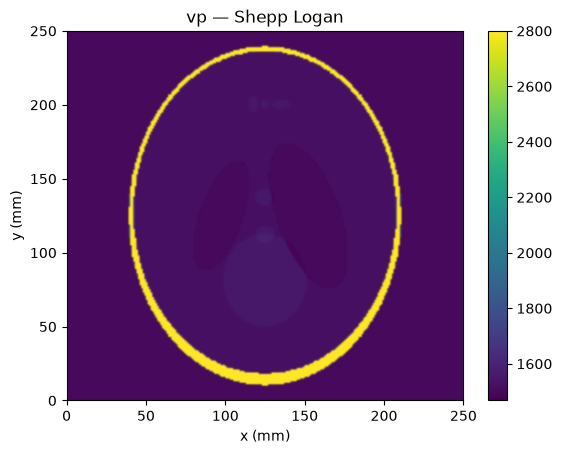

<Axes: title={'center': 'vp — Shepp Logan'}, xlabel='x (mm)', ylabel='y (mm)'>

In [5]:
phantom = np.rot90(shepp_logan_phantom(), k=1).astype(np.float32)
phantom = resize(
    phantom,
    INTERIOR,
    anti_aliasing=True,
    mode="reflect",
    preserve_range=True,
).astype(np.float32)

phantom -= phantom.min()
if phantom.max() > 0:
    phantom /= phantom.max()

vp_array = np.full(INTERIOR, SOS_WATER, dtype=np.float32)

head = phantom > 0.05
vp_array[head] = 1450.0 + 350.0 * phantom[head]
vp_array[phantom > 0.72] = SOS_SKULL

vp = ScalarField(name="vp", grid=problem.grid)
vp.allocate()
vp.fill(SOS_WATER)
vp.data[:] = vp_array
problem.medium.add(vp)

vp.plot(title="vp — Shepp Logan")


## 5. Transducers, geometry, acquisitions (tutorial 02 / 03)

Elliptical array, source at 200 kHz.

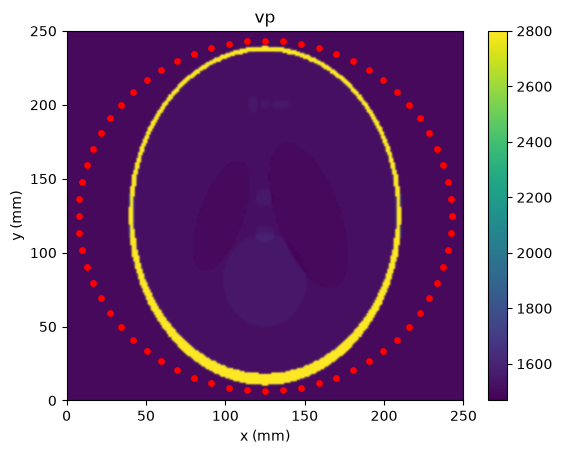

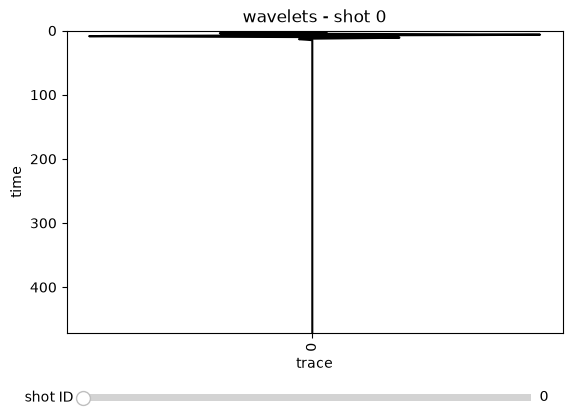

In [6]:
problem.transducers.default()
problem.geometry.default("elliptical", N_RECEIVERS)
problem.acquisitions.default()

for shot in problem.acquisitions.shots:
    shot.wavelets.data[0, :] = wavelets.tone_burst(
        F_CENTRE, N_CYCLES, time.num, time.step
    )

problem.plot()

## 6. Forward modelling (tutorial 03)

Loop over shots with a local PDE operator same physics as stride.forward, (without Mosaic)


In [7]:
from pathlib import Path

# Drop stale HDF5 only (do NOT rmtree output_folder — it defaults to cwd)
for h5 in Path(problem.output_folder).glob(f"{problem.name}-*.h5"):
    h5.unlink()
    print("Removed stale:", h5.name)

pde = IsoAcousticDevito(grid=problem.grid)

shot_ids = [s.id for s in problem.acquisitions.shots]
print(f"Running forward for {len(shot_ids)} shots …")

for i, shot_id in enumerate(shot_ids):
    sub = problem.sub_problem(shot_id)
    traces = await pde(
        sub.shot.wavelets,
        vp,
        problem=sub,
        **PDE_KWARGS,
    )
    shot = problem.acquisitions.get(shot_id)
    if not shot.observed.allocated:
        shot.observed.allocate()
    shot.observed.data[:] = traces.data
    shot.append_observed(path=problem.output_folder, project_name=problem.name)
    print(f"  shot {shot_id} ({i + 1}/{len(shot_ids)})")

print("Saved under:", problem.output_folder)



Removed stale: shepp_logan_250_64rc-Acquisitions.h5
Default Devito configuration:
	 * autotuning=['aggressive', 'runtime']
	 * develop-mode=False
	 * mpi=False
	 * log-level=DEBUG
	 * language=C
Running forward for 64 shots …
(ShotID 0) Preparing to run state for shot
(ShotID 0) Selected boundary type sponge_boundary_2
(ShotID 0) Estimated bandwidth for the propagated wavelet 0.104-0.295 MHz
(ShotID 0) Spatial grid spacing (1.004 mm | 4.959 PPW) is higher than dispersion limit (0.996 mm | 5.000 PPW)
(ShotID 0) Time grid spacing (0.108 μs | 30%) is below OT2 limit (0.161 μs)
(ShotID 0) Selected undersampling level 7
(ShotID 0) Selected time stepping scheme OT2
Operator `acoustic_iso_state` instance configuration:
	 * name=acoustic_iso_state
	 * subs={h_x: np.float32(0.0010040161), h_y: np.float32(0.0010040161), dt: 1.0757314974182443e-07}
	 * opt=advanced
	 * devicecreate=(p(t, x, y),)
Operator `acoustic_iso_state` generated in 0.87 s
  * lowering.Clusters: 0.56 s (64.7 %)
     * specia

## 7. one shot gather

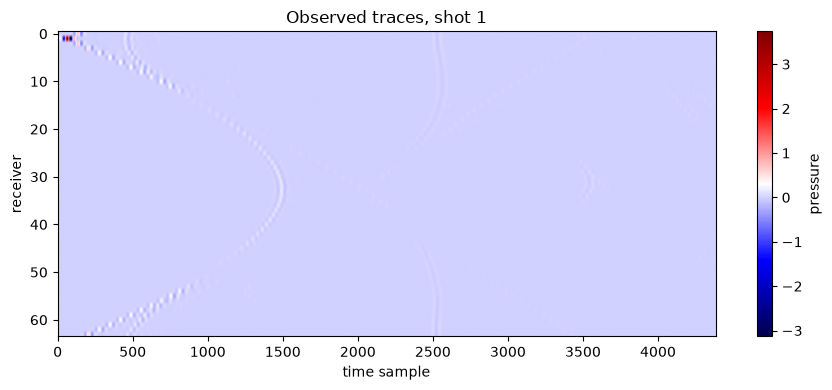

In [8]:
shot_id = 1
shot = problem.acquisitions.get(shot_id)
traces = np.asarray(shot.observed.data)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(traces, aspect="auto", origin="upper", cmap="seismic")
ax.set_title(f"Observed traces, shot {shot_id}")
ax.set_xlabel("time sample")
ax.set_ylabel("receiver")
fig.colorbar(im, ax=ax, label="pressure")
plt.tight_layout()
plt.show()
